##### **Import thư viện và đọc dữ liệu**

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent))
from config import DB_PATH, SNAPSHOTS, STATIC_FEATURES, DEMOGRAPHIC_COLS, BEHAVIORAL_STATIC_COLS, RANDOM_SEED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Kết nối database
conn = sqlite3.connect(DB_PATH)

assessment         = pd.read_sql("SELECT * FROM assessments", conn)
courses            = pd.read_sql("SELECT * FROM courses", conn)
student_info       = pd.read_sql("SELECT * FROM studentInfo", conn)
student_regs       = pd.read_sql("SELECT * FROM studentRegistration", conn)
student_assessment = pd.read_sql("SELECT * FROM studentAssessment", conn)
vle                = pd.read_sql("SELECT * FROM vle", conn)

##### **Tổng quan dữ liệu Assessment**

In [3]:
if 'module_presentation_length' not in assessment.columns:
    assessment = assessment.merge(courses, on=['code_module', 'code_presentation'])
assessment


,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
0,AAA,2013J,1752,TMA,19,10.0,268
1,AAA,2013J,1753,TMA,54,20.0,268
2,AAA,2013J,1754,TMA,117,20.0,268
3,AAA,2013J,1755,TMA,166,20.0,268
4,AAA,2013J,1756,TMA,215,30.0,268
...,...,...,...,...,...,...,...
201,GGG,2014J,37443,CMA,229,0.0,269
202,GGG,2014J,37435,TMA,61,0.0,269
203,GGG,2014J,37436,TMA,124,0.0,269
204,GGG,2014J,37437,TMA,173,0.0,269


In [4]:
assessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 206 non-null    object 
 1   code_presentation           206 non-null    object 
 2   id_assessment               206 non-null    int64  
 3   assessment_type             206 non-null    object 
 4   date                        206 non-null    object 
 5   weight                      206 non-null    float64
 6   module_presentation_length  206 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 11.4+ KB


In [5]:
assessment['id_assessment'] = assessment['id_assessment'].astype('object')

**Thống kê mô tả Assessment**

In [6]:
assessment.describe(include='object').T

,count,unique,top,freq
code_module,206,7,FFF,52
code_presentation,206,4,2014J,57
id_assessment,206,206,1752,1
assessment_type,206,3,TMA,106
date,206,75,222,15


- Dataset gồm 7 module: AAA, BBB, CCC, DDD, EEE, FFF và GGG. Trong đó FFF có nhiều assessment nhất với 52 bài. 

- Về thời điểm học, có 4 presentation: 2013B, 2013J, 2014B và 2014J. `B` tức là module bắt đầu học từ tháng 2, `J` tức là module bắt đầu học từ tháng 10.

- Có 3 loại assessment là: TMA, CMA, Exam. Trong đó TMA chiếm nhiều nhất với 106/206 bài (~51%).

- Có tất cả 206 `id_assessment` đều là duy nhất (unique = 206) → **không có assessment nào bị trùng lặp** trong dataset.

**Phân phối Module theo biểu đồ cột**

Text(0.5, 1.0, 'Distribution of Code Modules')

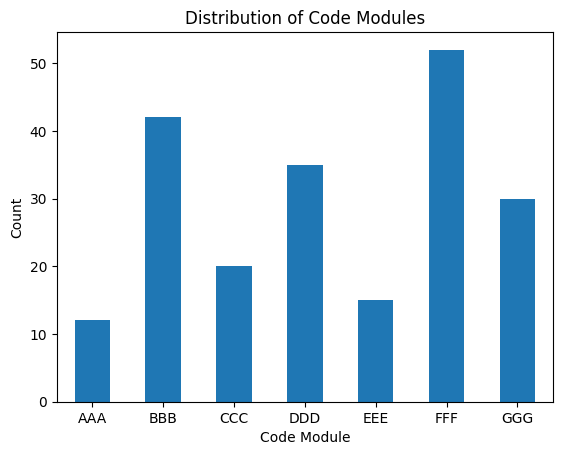

In [7]:
assessment['code_module'].value_counts().sort_index().plot(kind = 'bar', rot = 0)
plt.ylabel('Count')
plt.xlabel('Code Module')
plt.title('Distribution of Code Modules')

**Tỷ lệ loại Assessment theo biểu đồ tròn**

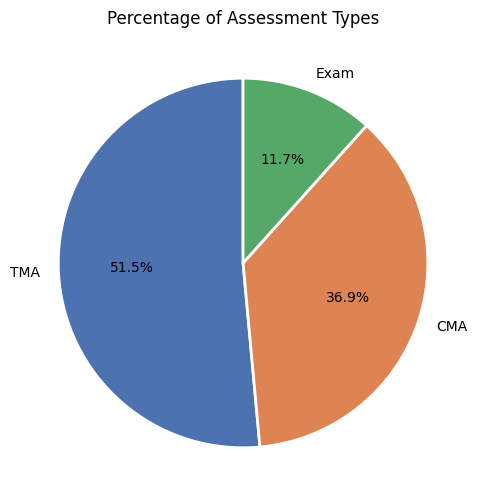

In [8]:
assessment['assessment_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452', '#55A868'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    title='Percentage of Assessment Types',
    figsize=(6, 6)
)

plt.ylabel('')  # ẩn label 'assessment_type' mặc định ở trục y
plt.show()

**Tính tổng trọng số Assessment**

In [9]:
assessment[['code_module','code_presentation','weight']].groupby(['code_module','code_presentation']).sum()

weight
code_module code_presentation        
AAA         2013J               200.0
            2014J               200.0
BBB         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
CCC         2014B               300.0
            2014J               300.0
DDD         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
EEE         2013J               200.0
            2014B               200.0
            2014J               200.0
FFF         2013B               200.0
            2013J               200.0
            2014B               200.0
            2014J               200.0
GGG         2013J               100.0
            2014B               100.0
            2014J               100.0

**Phát hiện bất thường trong trọng số GGG và CCC**

In [10]:
assessment[assessment['code_module'] == 'GGG'].head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
176,GGG,2013J,37418,CMA,229,0.0,261
177,GGG,2013J,37419,CMA,229,0.0,261
178,GGG,2013J,37420,CMA,229,0.0,261
179,GGG,2013J,37421,CMA,229,0.0,261
180,GGG,2013J,37422,CMA,229,0.0,261


In [11]:
assessment[assessment['code_module'] == 'CCC']

,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
54,CCC,2014B,24286,CMA,18,2.0,241
55,CCC,2014B,24287,CMA,67,7.0,241
56,CCC,2014B,24288,CMA,137,8.0,241
57,CCC,2014B,24289,CMA,207,8.0,241
58,CCC,2014B,24282,TMA,32,9.0,241
59,CCC,2014B,24283,TMA,102,22.0,241
60,CCC,2014B,24284,TMA,151,22.0,241
61,CCC,2014B,24285,TMA,200,22.0,241
62,CCC,2014B,24290,Exam,?,100.0,241
63,CCC,2014B,40087,Exam,?,100.0,241


- Phần lớn modules (AAA, BBB, DDD, EEE, FFF) có tổng weight = 200, mang tính nhất quán.
- Không phải module nào cũng chạy đủ 4 kỳ (`2013B`, `2013J`, `2014B`, `2014J`) — ví dụ AAA chỉ có `2013J` và `2014J`.

**Điểm bất thường:**

- GGG có tổng weight = 100: tất cả TMA và CMA của GGG đều có `weight = 0.0`, chỉ Exam mới có `weight = 100.0`, nói cách khác, kết quả module phụ thuộc hoàn toàn vào bài kiểm tra cuối kì.

- CCC có tổng weight = 300: module CCC có 2 Exam trong mỗi presentation (mỗi cái `weight = 100`), cộng với TMA+CMA = 100 → tổng = 300.

- Ở module CCC, cột `date` tồn tại giá trị '?' trong các bản ghi có `assignment_types = 'Exam'`

**Kiểm tra missing values trong cột `date`**

In [12]:
assessment[assessment.date == '?']

,code_module,code_presentation,id_assessment,assessment_type,date,weight,module_presentation_length
5,AAA,2013J,1757,Exam,?,100.0,268
11,AAA,2014J,1763,Exam,?,100.0,269
23,BBB,2013B,14990,Exam,?,100.0,240
35,BBB,2013J,15002,Exam,?,100.0,268
47,BBB,2014B,15014,Exam,?,100.0,234
53,BBB,2014J,15025,Exam,?,100.0,262
62,CCC,2014B,24290,Exam,?,100.0,241
63,CCC,2014B,40087,Exam,?,100.0,241
72,CCC,2014J,24299,Exam,?,100.0,269
73,CCC,2014J,40088,Exam,?,100.0,269


- `date = '?'` chỉ xuất hiện ở loại `Exam`, không có ở TMA hay CMA → missing có tính hệ thống, không phải ngẫu nhiên.
- 11/24 exam rows bị thiếu ngày, chiếm gần một nửa (~45.8%).
- Mức độ thiếu theo module:
  - AAA, BBB, CCC: thiếu hoàn toàn — không có presentation nào có ngày thi chính xác.
  - DDD: chỉ thiếu 1 presentation (2014J), 3 presentation còn lại có đầy đủ.
  - EEE, FFF, GGG: đầy đủ ngày thi cho tất cả presentations.
- Khả năng cao các module bị thiếu có lịch thi linh hoạt nên không có ngày cố định trong hệ thống.
- Vì Exam thường ở cuối khoá học (ngoài window dự báo), ảnh hưởng thực tế của missing này là **không đáng kể**.


**Trích xuất dữ liệu VLE**

In [13]:
vle_weekly = pd.read_sql("""
    SELECT 
        sv.id_student,
        sv.code_module,
        sv.code_presentation,
        v.activity_type,
        CAST(FLOOR(CAST(sv.date AS FLOAT) / 7) AS INTEGER) AS week,
        SUM(sv.sum_click) AS weekly_clicks
    FROM studentVle sv
    JOIN vle v 
        ON sv.id_site = v.id_site
        AND sv.code_module = v.code_module
        AND sv.code_presentation = v.code_presentation
    GROUP BY sv.id_student, sv.code_module, sv.code_presentation, v.activity_type, week
""", conn)

In [14]:
vle_weekly.sort_values(['id_student', 'code_module', 'code_presentation', 'week', 'activity_type'], inplace=True)
vle_weekly_agg = (
    vle_weekly
    .groupby(['id_student', 'code_module', 'code_presentation', 'week'], as_index=False)
    .agg(weekly_clicks=('weekly_clicks', 'sum'))
)
vle_weekly_agg


,id_student,code_module,code_presentation,week,weekly_clicks
0,6516,AAA,2014J,-4,110
1,6516,AAA,2014J,-3,48
2,6516,AAA,2014J,-2,2
3,6516,AAA,2014J,-1,96
4,6516,AAA,2014J,0,229
...,...,...,...,...,...
627026,2698588,BBB,2014J,32,13
627027,2698588,BBB,2014J,33,147
627028,2698588,BBB,2014J,34,12
627029,2698588,BBB,2014J,35,7


In [15]:
vle_weekly_agg.describe().apply(lambda x: x.apply('{:.2f}'.format))

,id_student,week,weekly_clicks
count,627031.00,627031.00,627031.00
mean,716245.32,14.06,63.16
std,563638.18,11.02,96.59
min,6516.00,-4.00,1.00
25%,505773.00,4.00,9.00
50%,589295.00,13.00,30.00
75%,645183.00,23.00,78.00
max,2698588.00,38.00,6999.00


- `vle_weekly_agg` gồm **627,031** bản ghi — sau khi gộp `activity_type`, số dòng giảm ~4 lần so với `vle_weekly` (2,518,170), mỗi bản ghi là tổng click của 1 sinh viên trong 1 tuần.

- Cột `week`:
    - Tuần được tính bằng `floor(date / 7)`, tính từ ngày bắt đầu module.
    - Giá trị âm (`min = -4`) cho thấy một số sinh viên đã truy cập VLE trước khi khoá học chính thức bắt đầu.
    - 50% bản ghi nằm trong tuần 4–23, tương ứng giai đoạn giữa khoá học.
    - `max = 38` (~9.5 tháng) phù hợp với độ dài các module trong OULAD (~240–270 ngày).

- Cột `weekly_clicks`:
    - Phân phối lệch phải nặng: median = 30 nhưng mean = 63.16 chứng tỏ dữ liệu bị kéo lên bởi outliers. Trong đó có các outlier cực đoan ví dụ như `max = 6,999` trong khi Q3 = 78.
    - `std = 96.59 > mean = 63.16` cho thấy độ phân tán rất lớn.


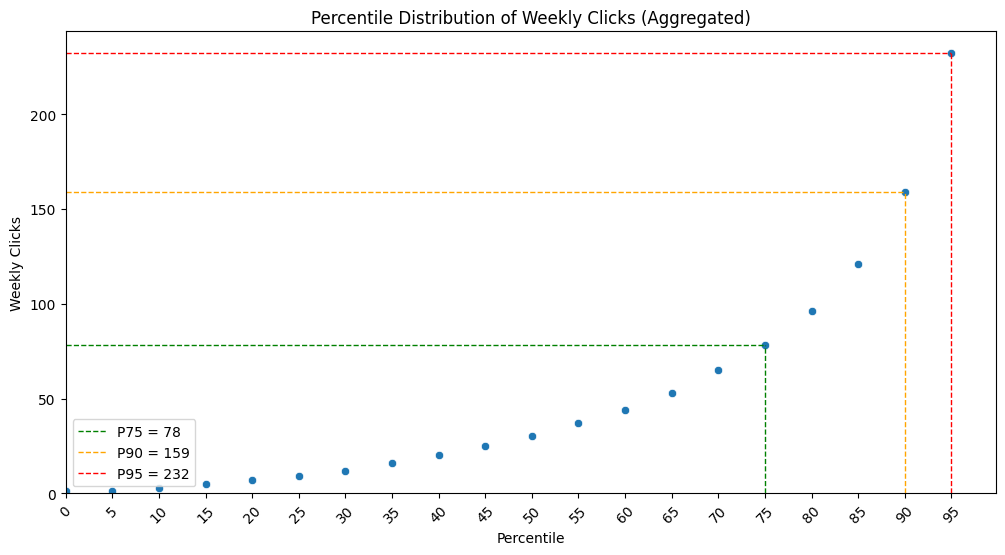

In [16]:
percentiles = range(0, 100, 5)
values = [vle_weekly_agg['weekly_clicks'].quantile(p / 100) for p in percentiles]

p75 = vle_weekly_agg['weekly_clicks'].quantile(0.75)
p90 = vle_weekly_agg['weekly_clicks'].quantile(0.90)
p95 = vle_weekly_agg['weekly_clicks'].quantile(0.95)

plt.figure(figsize=(12, 6))
sns.scatterplot(x=list(percentiles), y=values)

plt.plot([75, 75], [0, p75], color='green', linestyle='--', linewidth=1)
plt.plot([0, 75],  [p75, p75], color='green', linestyle='--', linewidth=1, label=f'P75 = {p75:.0f}')

plt.plot([90, 90], [0, p90], color='orange', linestyle='--', linewidth=1)
plt.plot([0, 90],  [p90, p90], color='orange', linestyle='--', linewidth=1, label=f'P90 = {p90:.0f}')

plt.plot([95, 95], [0, p95], color='red', linestyle='--', linewidth=1)
plt.plot([0, 95],  [p95, p95], color='red', linestyle='--', linewidth=1, label=f'P95 = {p95:.0f}')

plt.xlim(left=0)
plt.ylim(bottom=0)
plt.title('Percentile Distribution of Weekly Clicks (Aggregated)')
plt.xlabel('Percentile')
plt.xticks(range(0, 100, 5), rotation=45)
plt.ylabel('Weekly Clicks')
plt.legend()
plt.show()

- Từ P0 đến P75, weekly_clicks tăng chậm từ 1 đến 80 — phần lớn sinh viên tương tác ở mức vừa phải mỗi tuần.
- Từ P75 trở đi đường cong dốc lên nhanh, dấu hiệu của phân phối lệch phải với đuôi dài.
- P90 = 159, P95 = 232 — 10% sinh viên tích cực nhất có lượng click gấp ~2.5 lần mức trung bình (mean = 63.16).


**Số sinh viên còn lại theo từng tháng**

In [17]:
student_regs['date_unregistration'] = pd.to_numeric(
    student_regs['date_unregistration'], errors='coerce'
).astype('float')

In [18]:
from src.features.build_features import build_snapshot_dataset

Gọi `build_snapshot_dataset()` để tạo dataset dạng panel — mỗi sinh viên có tối đa 8 snapshot tương ứng 8 mốc thời gian dự báo. Chi tiết logic xem docstring trong `src/features/build_features.py`.

In [19]:
final_df = build_snapshot_dataset(conn)
final_df = final_df[[c for c in final_df.columns if c != 'final_result'] + ['final_result']]
final_df

,id_student,code_module,code_presentation,gender,region,age_band,imd_band,highest_education,disability,num_of_prev_attempts,...,date_unregistration,total_clicks,active_weeks,avg_weekly_clicks,num_submitted,avg_days_early,num_failed,avg_score,prediction_point,final_result
0,11391,AAA,2013J,M,East Anglian Region,55<=,90-100%,HE Qualification,N,0,...,NaN,427.0,5.0,85.400000,1.0,1.00,0.0,78.00,30,Pass
1,28400,AAA,2013J,F,Scotland,35-55,20-30%,HE Qualification,N,0,...,NaN,625.0,7.0,89.285714,1.0,-3.00,0.0,70.00,30,Pass
2,31604,AAA,2013J,F,South East Region,35-55,50-60%,A Level or Equivalent,N,0,...,NaN,566.0,7.0,80.857143,1.0,2.00,0.0,72.00,30,Pass
3,32885,AAA,2013J,F,West Midlands Region,0-35,50-60%,Lower Than A Level,N,0,...,NaN,585.0,7.0,83.571429,1.0,-7.00,0.0,69.00,30,Pass
4,38053,AAA,2013J,M,Wales,35-55,80-90%,A Level or Equivalent,N,0,...,NaN,764.0,7.0,109.142857,1.0,0.00,0.0,79.00,30,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178289,2681198,FFF,2014J,M,East Anglian Region,35-55,70-80%,Lower Than A Level,N,0,...,NaN,3926.0,35.0,112.171429,5.0,11.60,1.0,50.50,240,Pass
178290,2682682,FFF,2014J,F,East Midlands Region,0-35,60-70%,A Level or Equivalent,Y,0,...,NaN,3530.0,33.0,106.969697,5.0,-2.00,0.0,90.25,240,Distinction
178291,2683857,FFF,2014J,M,South West Region,35-55,70-80%,Lower Than A Level,N,1,...,NaN,8339.0,36.0,231.638889,3.0,1.33,0.0,73.67,240,Pass
178292,2693932,FFF,2014J,M,West Midlands Region,0-35,90-100%,A Level or Equivalent,N,1,...,NaN,2596.0,33.0,78.666667,4.0,3.75,0.0,89.33,240,Pass


In [20]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178294 entries, 0 to 178293
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_student            178294 non-null  int64  
 1   code_module           178294 non-null  object 
 2   code_presentation     178294 non-null  object 
 3   gender                178294 non-null  object 
 4   region                178294 non-null  object 
 5   age_band              178294 non-null  object 
 6   imd_band              178294 non-null  object 
 7   highest_education     178294 non-null  object 
 8   disability            178294 non-null  object 
 9   num_of_prev_attempts  178294 non-null  int64  
 10  studied_credits       178294 non-null  int64  
 11  date_registration     178294 non-null  object 
 12  date_unregistration   16086 non-null   float64
 13  total_clicks          175259 non-null  float64
 14  active_weeks          175259 non-null  float64
 15  

In [21]:
null_df = pd.DataFrame({
    "column": final_df.columns,
    "null_count": final_df.isnull().sum().values,
    "null_percent (%)": (final_df.isnull().sum() / len(final_df) * 100).round(2).values
})

null_df = null_df[null_df["null_count"] > 0].sort_values("null_percent (%)", ascending=False).reset_index(drop=True)

null_df


,column,null_count,null_percent (%)
0,date_unregistration,162208,90.98
1,avg_score,18532,10.39
2,num_submitted,16183,9.08
3,avg_days_early,16183,9.08
4,num_failed,16183,9.08
5,avg_weekly_clicks,3035,1.70
6,total_clicks,3035,1.70
7,active_weeks,3035,1.70


- Tổng quan:
    - Dataset gồm 178,294 dòng và 22 cột, bao gồm thông tin nhân khẩu học, hành vi học tập (VLE), kết quả bài tập và kết quả cuối kỳ.
    - Dataset có đa dạng kiểu dữ liệu: `object` (10 cột), `float64` (10 cột), `int64` (2 cột).

- Phân tích missing values:

    - `date_unregistration` thiếu nhiều nhất (~91.0%) vì phần lớn sinh viên không hủy đăng ký môn học.
    - Các cột VLE (total_clicks, active_weeks, avg_weekly_clicks) thiếu ~1.7%, có thể do sinh viên chưa tương tác hệ thống.
    - Các cột assessment (avg_score, num_submitted,...) thiếu đáng kể (~9-10%), do một số sinh viên chưa nộp bài tại thời điểm prediction_point.


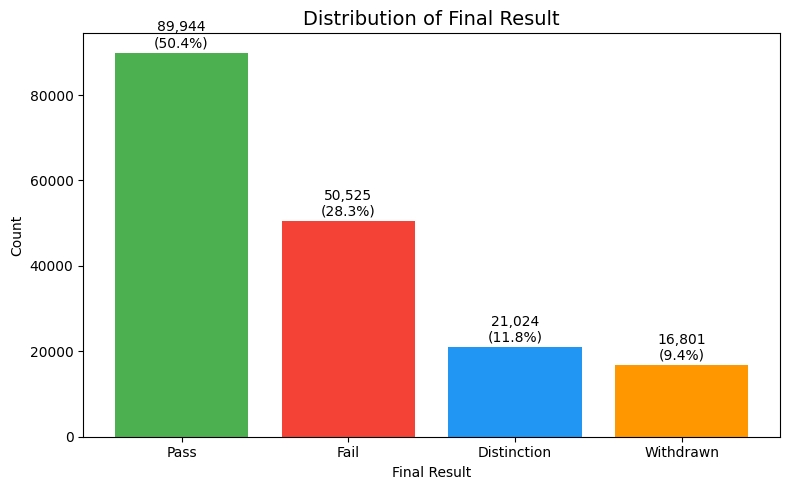

In [22]:
counts = final_df["final_result"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color=["#4CAF50", "#F44336", "#2196F3", "#FF9800"])

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"{val:,}\n({val/len(final_df)*100:.1f}%)",
             ha="center", va="bottom", fontsize=10)

plt.title("Distribution of Final Result", fontsize=14)
plt.xlabel("Final Result")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


- Pass chiếm tỷ lệ cao nhất với 89,944 bản ghi (50.4%) — khoảng một nửa lượt đăng ký module kết thúc ở mức đạt yêu cầu.
- Fail đứng thứ hai với 50,525 bản ghi (28.3%) — gần 1/3 lượt đăng ký không qua môn, đây là nhóm quan trọng cần dự đoán sớm.
- Distinction chiếm 11.8% (21,024 bản ghi) — nhóm sinh viên xuất sắc, chiếm khoảng 19% trong tổng số bản ghi đạt yêu cầu.
- Withdrawn chiếm 9.4% (16,801 bản ghi) — lượt đăng ký bị hủy giữa chừng, thường có dấu hiệu sớm qua hành vi tương tác thấp.
- Lưu ý: mỗi bản ghi là một cặp **(sinh viên, module, kì học)** tại một snapshot T — một sinh viên có thể xuất hiện nhiều lần nếu đăng ký nhiều module hoặc nhiều kì.
- Với bài toán early risk warning, ta có thể gộp Distinction vào nhóm Pass, vì phân biệt hai nhóm này không cần thiết khi mục tiêu là phát hiện sinh viên có nguy cơ trượt môn hoặc nghỉ học.

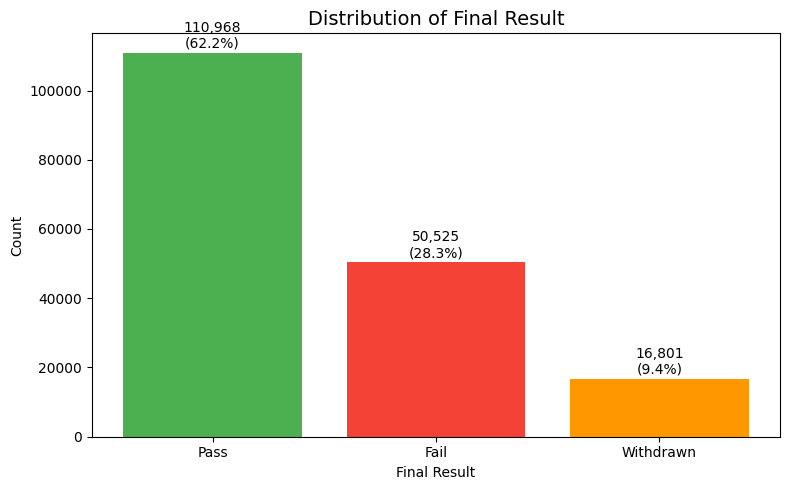

In [23]:
final_df["final_result"] = final_df["final_result"].replace("Distinction", "Pass")

counts = final_df["final_result"].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color=["#4CAF50", "#F44336", "#FF9800"])

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"{val:,}\n({val/len(final_df)*100:.1f}%)",
             ha="center", va="bottom", fontsize=10)

plt.title("Distribution of Final Result", fontsize=14)
plt.xlabel("Final Result")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Sau khi gộp nhóm Distinction vào nhóm Pass, ta có tỷ lệ Pass : Fail : Withdrawn = 62.2% : 28.3% : 9.4% cho thấy dataset có mất cân bằng nhãn ở mức vừa phải

**Chia tập Train-Test**

Sau khi xây dựng xong `final_df`, tập dữ liệu được chia thành tập huấn luyện (train) và tập kiểm tra (test) theo `id_student` — đảm bảo toàn bộ lịch sử của một sinh viên chỉ xuất hiện trong một tập duy nhất.Việc chia theo `id_student` thay vì theo hàng đảm bảo toàn bộ các snapshot của một sinh viên chỉ nằm trong một tập duy nhất. Nếu chia theo hàng, cùng một sinh viên có thể xuất hiện ở cả train lẫn test với các snapshot khác nhau — khi đó mô hình đã "thấy trước" hành vi của người đó lúc huấn luyện.

Tỉ lệ chia được chọn là train:test = 80:20.


In [24]:
from sklearn.model_selection import train_test_split

def splitting(df):
    train_ids, test_ids = train_test_split(
        df['id_student'].unique(),
        test_size=0.2,
        random_state=RANDOM_SEED
    )

    train_df = df[df['id_student'].isin(train_ids)].reset_index(drop=True)
    test_df  = df[df['id_student'].isin(test_ids)].reset_index(drop=True)

    print(f"Train: {train_df['id_student'].nunique():,} students, {len(train_df):,} rows")
    print(f"Test:  {test_df['id_student'].nunique():,} students, {len(test_df):,} rows")
    return train_df, test_df

train, test = splitting(final_df)

Train: 17,921 students, 142,384 rows
Test:  4,481 students, 35,910 rows


Tập train gồm 17,921 sinh viên với 142,384 snapshot, tập test gồm 4,481 sinh viên với 35,910 snapshot — tỉ lệ xấp xỉ 80/20. 

In [25]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142384 entries, 0 to 142383
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_student            142384 non-null  int64  
 1   code_module           142384 non-null  object 
 2   code_presentation     142384 non-null  object 
 3   gender                142384 non-null  object 
 4   region                142384 non-null  object 
 5   age_band              142384 non-null  object 
 6   imd_band              142384 non-null  object 
 7   highest_education     142384 non-null  object 
 8   disability            142384 non-null  object 
 9   num_of_prev_attempts  142384 non-null  int64  
 10  studied_credits       142384 non-null  int64  
 11  date_registration     142384 non-null  object 
 12  date_unregistration   12920 non-null   float64
 13  total_clicks          139934 non-null  float64
 14  active_weeks          139934 non-null  float64
 15  

**Kiểm tra dấu `?` trong các cột**

In [26]:
# Tìm các cột có chứa dấu '?'
cols_with_question = [col for col in train.columns if (train[col] == '?').any()]

print(f"Số cột có dấu '?': {len(cols_with_question)}")
print(f"Các cột có dấu '?': {cols_with_question}")

Số cột có dấu '?': 2
Các cột có dấu '?': ['imd_band', 'date_registration']


In [27]:
print(f"Số lượng missing value ở cột imd_band: {len(train[train['imd_band'] == '?'])}")
print(f"Tỉ lệ missing value ở cột imd_band: {len(train[train['imd_band'] == '?']) / len(train) * 100:.2f}%")

Số lượng missing value ở cột imd_band: 5986
Tỉ lệ missing value ở cột imd_band: 4.20%


##### **Phân tích khám phá các đặc trưng tĩnh**

Ta tách thông tin tĩnh của sinh viên thành hai dataframe:
- **`unique_students`**: thuần thông tin nhân khẩu học (`gender`, `region`, `age_band`, `imd_band`, `highest_education`, `disability`), dedup theo `id_student`.
- **`student_academic_profile`**: các đặc trưng hành vi tĩnh (`num_of_prev_attempts`, `studied_credits`) gắn với từng enrollment (`code_module`, `code_presentation`) và nhãn `final_result` để phân tích tương quan với kết quả học tập.

In [28]:
unique_students = (
    train[["id_student"] + DEMOGRAPHIC_COLS]
    .drop_duplicates(subset="id_student")
    .reset_index(drop=True)
)

student_academic_profile = (
    train[["id_student", "code_module", "code_presentation"] + BEHAVIORAL_STATIC_COLS + ["final_result"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

In [29]:
unique_students

,id_student,gender,region,age_band,imd_band,highest_education,disability
0,11391,M,East Anglian Region,55<=,90-100%,HE Qualification,N
1,28400,F,Scotland,35-55,20-30%,HE Qualification,N
2,31604,F,South East Region,35-55,50-60%,A Level or Equivalent,N
3,38053,M,Wales,35-55,80-90%,A Level or Equivalent,N
4,45462,M,Scotland,0-35,30-40%,HE Qualification,N
...,...,...,...,...,...,...,...
17916,2678580,M,North Western Region,0-35,60-70%,A Level or Equivalent,N
17917,2682682,F,East Midlands Region,0-35,60-70%,A Level or Equivalent,Y
17918,2682745,F,London Region,35-55,30-40%,HE Qualification,N
17919,2686035,F,South East Region,0-35,90-100%,Lower Than A Level,N


In [30]:
unique_students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17921 entries, 0 to 17920
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_student         17921 non-null  int64 
 1   gender             17921 non-null  object
 2   region             17921 non-null  object
 3   age_band           17921 non-null  object
 4   imd_band           17921 non-null  object
 5   highest_education  17921 non-null  object
 6   disability         17921 non-null  object
dtypes: int64(1), object(6)
memory usage: 980.2+ KB


Trong các thông tin về nhân khẩu học của sinh viên, ta đã biết cột `imd_band` có tồn tại missing value (giá trị '?'). Đây là chỉ số đo mức độ thiếu thốn kinh tế theo khu vực địa lý, được kỳ vọng có liên quan đến kết quả học tập. Trước khi phân tích, cần kiểm tra phân phối của cột này để đánh giá mức độ missing và độ cân bằng giữa các nhóm

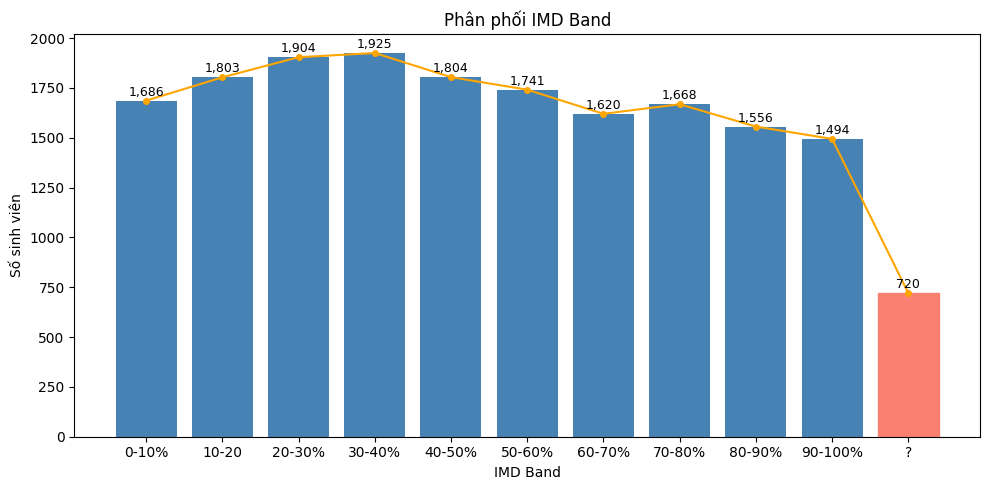

In [31]:
imd_order = ['0-10%', '10-20', '20-30%', '30-40%', '40-50%',
             '50-60%', '60-70%', '70-80%', '80-90%', '90-100%', '?']

counts = unique_students['imd_band'].value_counts().reindex(imd_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color='steelblue')
bars[-1].set_color('salmon')

# Đường nối đỉnh
x_centers = [bar.get_x() + bar.get_width() / 2 for bar in bars]
ax.plot(x_centers, counts.values, color='orange', linewidth=1.5, marker='o', markersize=4)

ax.set_title('Phân phối IMD Band')
ax.set_xlabel('IMD Band')
ax.set_ylabel('Số sinh viên')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Phân phối `imd_band` tập trung cao nhất ở band 30-40% (1,925 sinh viên) và có xu hướng giảm dần về hai phía. Nhìn chung, sinh viên có xu hướng tập trung ở các khu vực có mức độ thiếu thốn kinh tế trung bình đến cao hơn là các khu vực khá giả. Đáng chú ý là có 720 sinh viên (~4.2%) mang giá trị ?, cần được xử lý trước khi đưa vào mô hình.

In [32]:
# Tỷ lệ % region theo từng imd_band + count
result = (
    unique_students.groupby(['imd_band', 'region'])
    .size()
    .reset_index(name='count')
)

result['percent'] = (
    result.groupby('imd_band')['count']
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

print(result[result['imd_band'] == '?'].sort_values('count', ascending=False).to_string(index=False))

imd_band               region  count  percent
       ?         North Region    467    64.86
       ?              Ireland    183    25.42
       ?         South Region     35     4.86
       ? West Midlands Region     25     3.47
       ?             Scotland      4     0.56
       ?    South West Region      3     0.42
       ?     Yorkshire Region      2     0.28
       ? North Western Region      1     0.14


Giá trị `?` trong `imd_band` tập trung gần như hoàn toàn ở hai vùng: North Region (64.86%) và Ireland (25.42%) — cộng lại chiếm ~90.3% tổng số missing. Các vùng còn lại chỉ đóng góp ~9.7%.


In [33]:
imd_by_region = (
    pd.crosstab(unique_students['region'], unique_students['imd_band'], normalize='index') * 100
).round(2)

imd_by_region = imd_by_region.sort_values('?', ascending=False)

display(
    imd_by_region.style
    .format("{:.2f}%")
    .background_gradient(cmap='YlOrRd', axis=1)
    .set_caption("Phân phối imd_band (%) theo Region")
    .set_table_styles([
        {'selector': 'caption',  'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'table',    'props': [('border-collapse', 'collapse'), ('width', '100%'), ('font-size', '14px')]},
        {'selector': 'th, td',   'props': [('padding', '8px 14px'), ('text-align', 'center')]},
        {'selector': '',         'props': [('overflow-y', 'auto'), ('max-height', '500px'), ('display', 'block')]},
    ])
)


imd_band,0-10%,10-20,20-30%,30-40%,40-50%,50-60%,60-70%,70-80%,80-90%,90-100%,?
region,,,,,,,,,,,
North Region,8.11%,10.85%,6.74%,5.96%,5.87%,3.71%,3.52%,4.69%,4.50%,0.39%,45.65%
Ireland,9.72%,10.10%,6.91%,7.80%,5.75%,8.82%,7.80%,6.65%,6.65%,6.39%,23.40%
South Region,1.05%,4.50%,5.73%,6.55%,10.93%,10.40%,8.88%,12.62%,15.55%,21.74%,2.05%
West Midlands Region,17.52%,14.43%,11.03%,8.99%,10.35%,7.48%,8.61%,8.99%,5.74%,4.98%,1.89%
South West Region,3.99%,7.29%,10.74%,15.57%,12.65%,12.19%,10.20%,12.58%,7.90%,6.67%,0.23%
Yorkshire Region,19.42%,12.21%,12.31%,10.48%,9.62%,9.62%,7.31%,10.48%,5.00%,3.37%,0.19%
Scotland,8.14%,7.76%,10.29%,11.27%,10.80%,12.21%,10.38%,9.49%,9.92%,9.54%,0.19%
North Western Region,23.09%,12.23%,13.46%,12.23%,7.79%,7.72%,7.10%,7.31%,5.67%,3.35%,0.07%
East Anglian Region,3.25%,4.60%,8.36%,10.38%,12.17%,11.33%,12.06%,12.73%,11.89%,13.24%,0.00%


- **North Region** (45.65%) và **Ireland** (23.40%) có tỷ lệ `?` vượt trội so với tất cả các vùng còn lại (đều khoảng từ 2% trở xuống).

- **North Western** (0-10%: 23.09%), **Yorkshire** (0-10%: 19.42%), **West Midlands** (0-10%: 17.52%) là các vùng có chỉ số imd mức thấp nhất chiếm tỉ trọng cao nhất. **London** (10-20%: 19.30%, 20-30%: 18.37%) cũng có mức độ tập trung cao ở các mức imd thấp.

- **South Region** (90-100%: 21.74%, 80-90%: 15.55%) và **South East Region** (60-70%: 13.95%, 90-100%: 12.40%) tập trung ở các band cao. **East Anglian Region** có xu hướng tương tự, với các band từ 40% trở lên dao động 10–13%.

- **Scotland**, **East Midlands**, **Wales** và **South West Region** không lệch rõ về phía nào, các band dao động tương đối đều trong khoảng 7–13%.

In [70]:
# Tỷ lệ % region theo từng imd_band + count
result = (
    unique_students.groupby(['imd_band', 'highest_education'])
    .size()
    .reset_index(name='count')
)

result['percent'] = (
    result.groupby('imd_band')['count']
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

print(result[result['imd_band'] == '?'].sort_values('count', ascending=False).to_string(index=False))

imd_band           highest_education  count  percent
       ?          Lower Than A Level    250    34.72
       ?            HE Qualification    191    26.53
       ?       A Level or Equivalent    187    25.97
       ? Post Graduate Qualification     77    10.69
       ?             No Formal quals     15     2.08


In [34]:
imd_by_edu = (
    pd.crosstab(unique_students['highest_education'], unique_students['imd_band'], normalize='index') * 100
).round(2)

imd_order = ['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%', '?']

edu_order = [
    'No Formal quals',
    'Lower Than A Level',
    'A Level or Equivalent',
    'HE Qualification',
    'Post Graduate Qualification'
]

imd_by_edu = imd_by_edu.reindex(edu_order).reindex(columns=imd_order)

display(
    imd_by_edu.style
    .format("{:.2f}%")
    .background_gradient(cmap='YlOrRd', axis=1)
    .set_caption("Phân phối IMD Band (%) theo Highest Education")
    .set_table_styles([
        {'selector': 'caption',  'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'table',    'props': [('border-collapse', 'collapse'), ('width', '100%'), ('font-size', '14px')]},
        {'selector': 'th, td',   'props': [('padding', '8px 14px'), ('text-align', 'center')]},
        {'selector': '',         'props': [('overflow-y', 'auto'), ('max-height', '500px'), ('display', 'block')]},
    ])
)

imd_band,0-10%,10-20,20-30%,30-40%,40-50%,50-60%,60-70%,70-80%,80-90%,90-100%,?
highest_education,,,,,,,,,,,
No Formal quals,18.75%,16.25%,22.50%,18.12%,1.88%,5.00%,5.62%,1.25%,0.00%,1.25%,9.38%
Lower Than A Level,11.43%,11.37%,11.55%,10.70%,10.05%,9.56%,8.59%,8.67%,7.95%,6.39%,3.72%
A Level or Equivalent,8.72%,9.90%,9.97%,10.89%,10.65%,10.16%,9.62%,10.02%,8.93%,8.80%,2.34%
HE Qualification,6.65%,7.45%,9.86%,10.60%,9.48%,9.48%,8.92%,9.76%,10.18%,10.95%,6.68%
Post Graduate Qualification,0.00%,4.35%,6.52%,1.63%,1.63%,3.80%,4.89%,1.63%,8.70%,25.00%,41.85%


- **No Formal quals** tập trung mạnh ở các band thấp: 20-30% (22.50%), 0-10% (18.75%), 30-40% (18.12%), 10-20% (16.25%) — gần như không xuất hiện ở band 80-90% (0.00%). Tỷ lệ `?` = 9.38%, cao thứ hai trong bảng.
- **Lower Than A Level** có xu hướng giảm dần từ band thấp đến band cao: từ 11.43% (0-10%) xuống 6.39% (90-100%), không có band nào chiếm ưu thế rõ rệt. Tỷ lệ `?` = 3.72%.
- **A Level or Equivalent** phân phối tương đối đồng đều qua tất cả các band (8–11%), không lệch rõ về phía nào. Tỷ lệ `?` = 2.34%.
- **HE Qualification** có xu hướng ngược với No Formal quals — phân bố đồng đều chủ yếu ở các band từ trung bình đến cao, đặc biệt nhóm 90-100% chiếm tỉ lệ lớn nhất: 10.95%. Tỷ lệ `?` = 6.68%.
- **Post Graduate Qualification** có tỷ lệ `?` cao nhất (41.85%), gần như không có sinh viên ở band 0-10% (0.00%), trong khi tập trung rõ nhất ở band 90-100% (25%). 

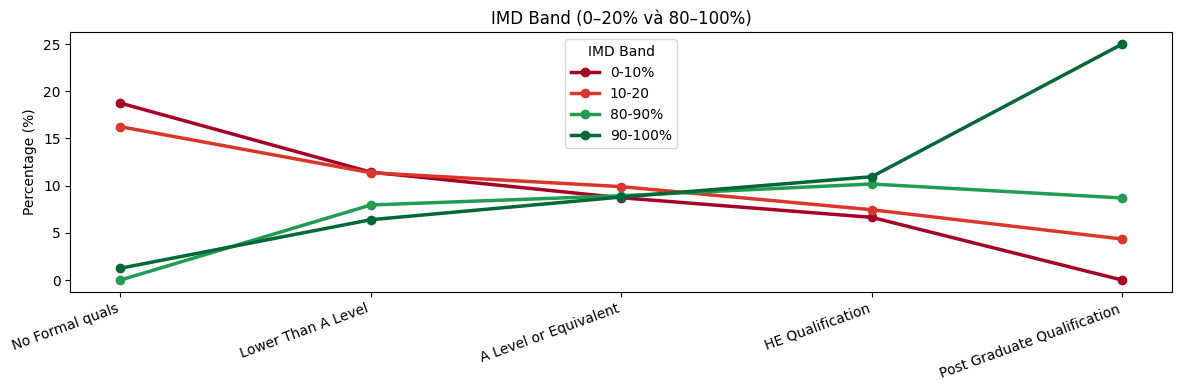

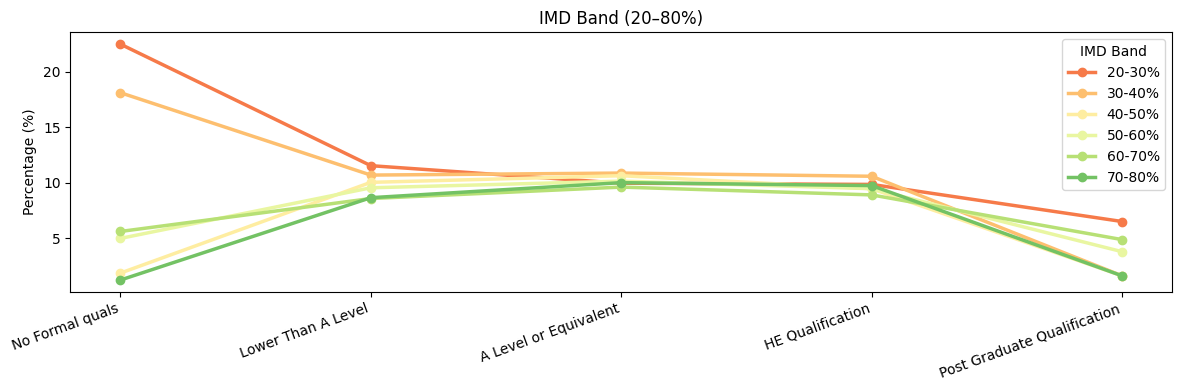

In [35]:
edu_order = [
    'No Formal quals',
    'Lower Than A Level',
    'A Level or Equivalent',
    'HE Qualification',
    'Post Graduate Qualification'
]

all_bands    = ['0-10%', '10-20', '20-30%', '30-40%', '40-50%',
                '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']
extreme_bands = ['0-10%', '10-20', '80-90%', '90-100%']
middle_bands  = ['20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%']

cmap   = plt.cm.RdYlGn
colors = {band: cmap(i / (len(all_bands) - 1)) for i, band in enumerate(all_bands)}

imd_by_edu = (
    pd.crosstab(unique_students['highest_education'], unique_students['imd_band'], normalize='index') * 100
).reindex(edu_order)

# Plot 1 — 4 band đầu và cuối
plt.figure(figsize=(12, 4))
for imd in extreme_bands:
    plt.plot(edu_order, imd_by_edu[imd], marker='o', label=imd, color=colors[imd], linewidth=2.5)
plt.xticks(range(len(edu_order)), edu_order, rotation=20, ha='right')
plt.ylabel('Percentage (%)')
plt.title('IMD Band (0–20% và 80–100%)')
plt.legend(title='IMD Band')
plt.tight_layout()
plt.show()

# Plot 2 — 6 band giữa
plt.figure(figsize=(12, 4))
for imd in middle_bands:
    plt.plot(edu_order, imd_by_edu[imd], marker='o', label=imd, color=colors[imd], linewidth=2.5)
plt.xticks(range(len(edu_order)), edu_order, rotation=20, ha='right')
plt.ylabel('Percentage (%)')
plt.title('IMD Band (20–80%)')
plt.legend(title='IMD Band')
plt.tight_layout()
plt.show()

**Biểu đồ 1 (band cực trị 0–20% và 80–100%):**

Hai band thấp (0-10%, 10-20%) và hai band cao (80-90%, 90-100%) thể hiện xu hướng hoàn toàn ngược chiều nhau theo trình độ học vấn. Band thấp giảm mạnh từ trái sang phải, trong khi band cao tăng dần — đặc biệt 90-100% tăng đột biến ở Post Graduate Qualification. Bốn đường gần như giao nhau quanh mức A Level or Equivalent, cho thấy đây là ngưỡng học vấn mà mối tương quan với imd_band bắt đầu đảo chiều.

**Biểu đồ 2 (band trung 20–80%):**

Các band trung gian có hành vi tương đồng nhau — đều bắt đầu phân tán ở No Formal quals, hội tụ về mức đồng đều tại A Level or Equivalent, rồi lại phân kỳ nhẹ ở Post Graduate Qualification. Không có band nào nổi bật hẳn so với phần còn lại, phản ánh mức độ thiếu thốn trung bình phân phối khá đồng đều qua các trình độ học vấn.

Tiếp theo, cột `disability` cho biết sinh viên có khai báo khuyết tật hay không. Biểu đồ dưới thể hiện tỷ lệ phân phối giữa hai nhóm trong tập train.

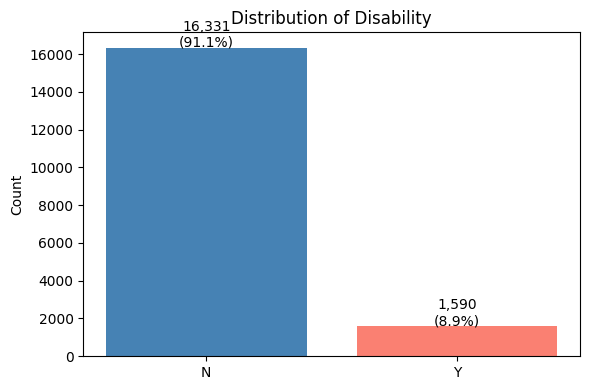

In [36]:
counts = unique_students['disability'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=['steelblue', 'salmon'])
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, f"{v:,}\n({v/len(unique_students)*100:.1f}%)", ha='center')
plt.title('Distribution of Disability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Để hiểu rõ hơn về nhóm sinh viên có khuyết tật, bảng dưới thể hiện tỷ lệ sinh viên khai báo khuyết tật (`Y`) trong từng nhóm `imd_band` — nhằm kiểm tra liệu mức độ thiếu thốn kinh tế có liên quan đến tỷ lệ khuyết tật hay không.

In [37]:
disabled_students = unique_students[unique_students['disability'] == 'Y']

result = (
    disabled_students['imd_band']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
result.columns = ['imd_band', 'disability percentage (%)']
result

,imd_band,disability percentage (%)
0,20-30%,13.40
1,10-20,12.70
2,0-10%,12.45
3,40-50%,11.82
4,30-40%,11.32
5,50-60%,8.36
6,60-70%,8.30
7,90-100%,7.42
8,70-80%,7.17
9,80-90%,5.72


- Phần lớn sinh viên trong tập train không khai báo khuyết tật, chiếm tỉ lệ 91.1%, nhóm có khuyết tật chỉ chiếm 8.9%.

- Có xu hướng nghịch biến rõ ràng giữa `imd_band` và tỷ lệ khuyết tật — các band thấp (0-40%) có tỷ lệ sinh viên khuyết tật cao hơn (11–13%), trong khi các band cao (70-100%) có tỷ lệ thấp hơn (5–7%). Điều này gợi ý rằng sinh viên thuộc khu vực thiếu thốn kinh tế hơn có xu hướng khai báo khuyết tật cao hơn, có thể phản ánh sự chênh lệch về khả năng tiếp cận hỗ trợ y tế và giáo dục giữa các nhóm kinh tế xã hội.

Tiếp theo, ta xem xét biến `num_of_prev_attempts` — số lần sinh viên đã đăng ký học module trước đây. Đây là đặc trưng phản ánh lịch sử học tập, cho biết liệu sinh viên đang học lần đầu hay đang retake sau khi thất bại ở kỳ trước.

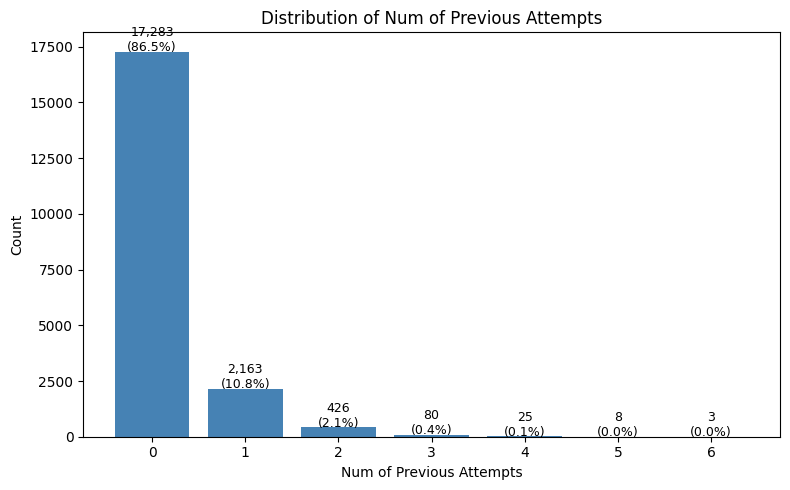

In [38]:
counts = student_academic_profile['num_of_prev_attempts'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color='steelblue')
for i, (idx, v) in enumerate(counts.items()):
    plt.text(idx, v + 20, f"{v:,}\n({v/len(student_academic_profile)*100:.1f}%)", ha='center', fontsize=9)
plt.xlabel('Num of Previous Attempts')
plt.ylabel('Count')
plt.title('Distribution of Num of Previous Attempts')
plt.xticks(counts.index)
plt.tight_layout()
plt.show()

Từ `num_of_prev_attempts`, ta tạo biến nhị phân `is_retake_the_course` để đơn giản hoá phân tích: giá trị `1` nếu sinh viên đã từng học module này trước đó, `0` nếu đây là lần đầu. Việc gộp tất cả các mức retake (1, 2, 3, ...) thành một nhóm duy nhất phản ánh đúng bản chất câu hỏi — quan trọng là *có hay không* từng thất bại, không phải thất bại bao nhiêu lần.

In [39]:
student_academic_profile['is_retake_the_course'] = student_academic_profile['num_of_prev_attempts'].apply(
    lambda x: 1 if x > 0 else x
)

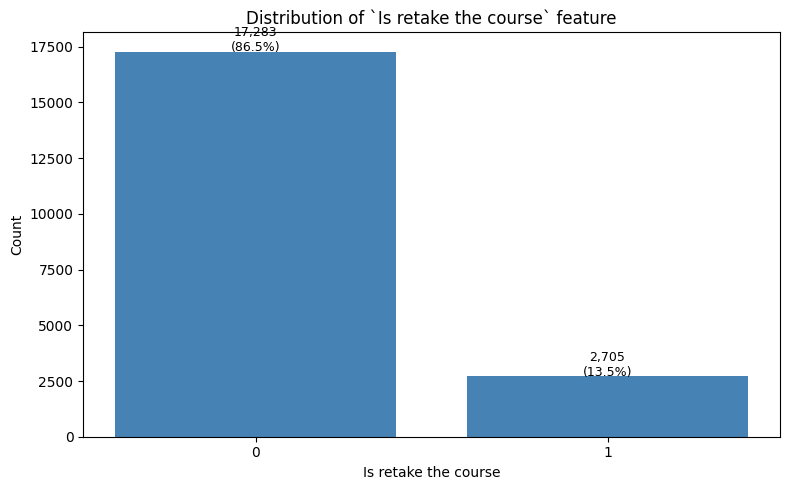

In [40]:
counts = student_academic_profile['is_retake_the_course'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color='steelblue')
for i, (idx, v) in enumerate(counts.items()):
    plt.text(idx, v + 20, f"{v:,}\n({v/len(student_academic_profile)*100:.1f}%)", ha='center', fontsize=9)
plt.xlabel('Is retake the course')
plt.ylabel('Count')
plt.title('Distribution of `Is retake the course` feature')
plt.xticks(counts.index)
plt.tight_layout()
plt.show()

Phần lớn sinh viên (86.5%) đăng ký học module lần đầu (`num_of_prev_attempts = 0`), trong khi 13.5% còn lại đã từng học một module bất kì một lần trước đó. Số lần retake giảm mạnh theo cấp số nhân — retake lần đầu chiếm 10.8%, retake lần hai chỉ còn 2.1%, và các trường hợp retake từ ba lần trở lên rất hiếm (< 0.5%). Điều này cho thấy đa số sinh viên không học lại module sau khi bị đánh trượt.

Để kiểm tra liệu tình trạng khuyết tật có liên quan đến xu hướng retake hay không, ta kết hợp `student_academic_profile` với thông tin `disability` từ `unique_students`, sau đó tính tỉ lệ retake trong từng nhóm.

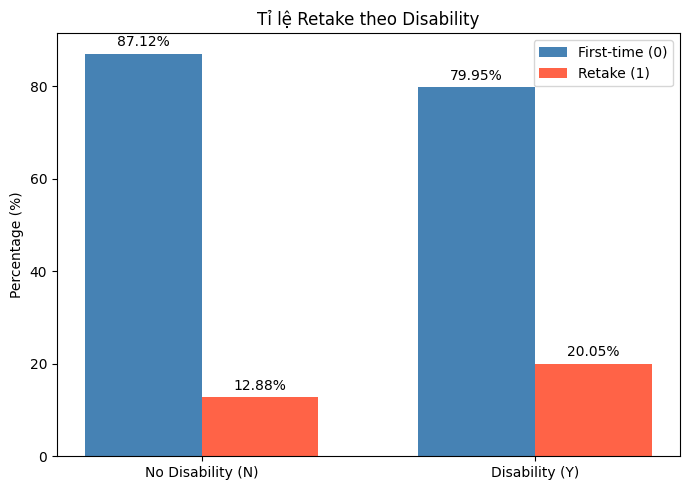

In [41]:
merged_retake = student_academic_profile.merge(
    unique_students[['id_student', 'disability']], on='id_student'
)

retake_disability = (
    pd.crosstab(merged_retake['disability'], merged_retake['is_retake_the_course'], normalize='index') * 100
).round(2)

x = np.arange(2)
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars0 = ax.bar(x - width/2, retake_disability.loc[['N', 'Y'], 0], width, label='First-time (0)', color='steelblue')
bars1 = ax.bar(x + width/2, retake_disability.loc[['N', 'Y'], 1], width, label='Retake (1)', color='tomato')
ax.bar_label(bars0, fmt='%.2f%%', padding=3)
ax.bar_label(bars1, fmt='%.2f%%', padding=3)
ax.set_xticks(x)
ax.set_xticklabels(['No Disability (N)', 'Disability (Y)'])
ax.set_ylabel('Percentage (%)')
ax.set_title('Tỉ lệ Retake theo Disability')
ax.legend()
plt.tight_layout()
plt.show()

Sinh viên có khuyết tật có tỉ lệ retake cao hơn rõ rệt (20.1%) so với nhóm không khuyết tật (12.9%). Điều này gợi ý rằng khuyết tật là một yếu tố rủi ro học tập — nhóm này gặp nhiều khó khăn hơn trong việc học tập, dẫn đến tần suất phải học lại cao hơn.

Ngoài yếu tố khuyết tật, ta cũng xem xét việc khối lượng học tập trong học kì (số tín chỉ) mà sinh viên đang đảm nhận có mối quan hệ gì với việc phải học lại các module không

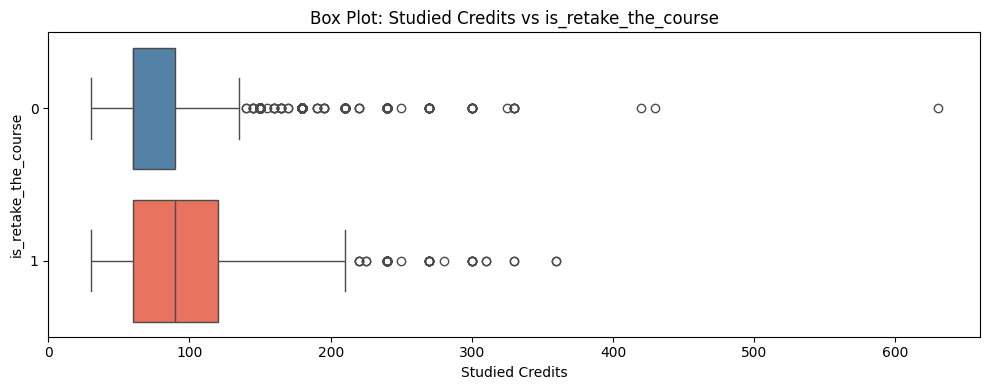

In [42]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=student_academic_profile,
    x='studied_credits',
    y='is_retake_the_course',
    orient='h',
    palette=['steelblue', 'tomato']
)
plt.xlabel('Studied Credits')
plt.ylabel('is_retake_the_course')
plt.title('Box Plot: Studied Credits vs is_retake_the_course')
plt.tight_layout()
plt.show()

In [43]:
student_academic_profile.groupby('is_retake_the_course')['studied_credits'].describe()

,count,mean,std,min,25%,50%,75%,max
is_retake_the_course,,,,,,,,
0,17283.0,77.763698,34.999642,30.0,60.0,60.0,90.0,630.0
1,2705.0,98.922366,47.413631,30.0,60.0,90.0,120.0,360.0


Sinh viên retake module có xu hướng đăng ký nhiều tín chỉ hơn đáng kể so với nhóm học lần đầu — median 90 tín chỉ so với 60, mean 98.9 so với 77.8. Phân phối của nhóm retake cũng rộng hơn (std ≈ 47 vs 35), cho thấy sự đa dạng hơn về khối lượng học tập. Điều này có thể phản ánh việc sinh viên retake chủ động đăng ký thêm module để bù đắp cho kỳ học trước, hoặc đây là nhóm có động lực học tập cao hơn vì đã từng thất bại.

##### Phân tích khám phá theo nhãn mục tiêu

Trước khi phân tích tương quan với nhãn, ta encode hai biến categorical thành dạng nhị phân: `disability` (`Y/N` → `1/0`) và `age_band` được rút gọn thành `is_U35` (`1` nếu thuộc nhóm tuổi 0–35, `0` nếu trên 35). Việc này giúp tính mean theo nhóm kết quả và vẽ radar chart ở các bước tiếp theo.

In [44]:
unique_students['disability'] = unique_students['disability'].apply(lambda x: 1 if x == 'Y' else 0)
unique_students['is_U35'] = unique_students['age_band'].apply(lambda x: 1 if x == '0-35' else 0)

In [45]:
analysis_df = student_academic_profile.merge(unique_students, on='id_student')

analysis_df.groupby('final_result')[['is_retake_the_course', 'studied_credits', 'num_of_prev_attempts',
                                       'disability', 'is_U35']].mean()

,is_retake_the_course,studied_credits,num_of_prev_attempts,disability,is_U35
final_result,,,,,
Fail,0.204879,80.976795,0.269139,0.095002,0.753669
Pass,0.096774,78.226710,0.117466,0.074094,0.677148
Withdrawn,0.154937,87.021139,0.194896,0.135602,0.714102


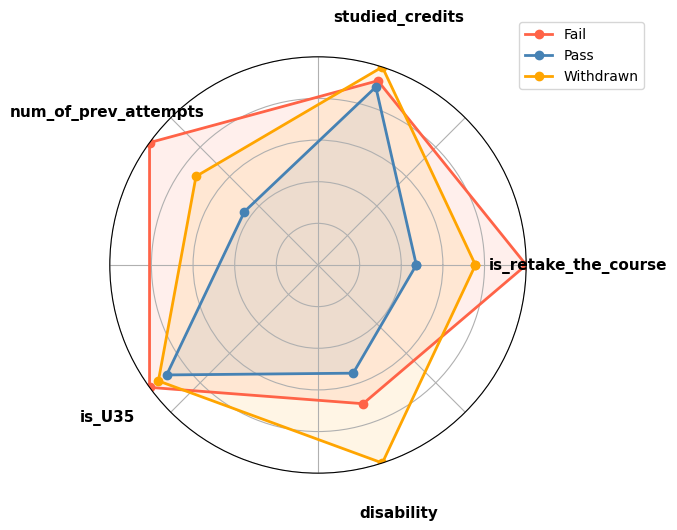

In [71]:
def plot_radar(df, categories, group_col, groups=None, colors=None):
    if groups is None:
        groups = df[group_col].unique().tolist()
    if colors is None:
        colors = ['tomato', 'steelblue', 'orange', 'green', 'purple'][:len(groups)]

    df_encoded = df.copy()
    for col in categories:
        if df_encoded[col].dtype == 'object':
            df_encoded[col] = (df_encoded[col] == 'Y').astype(int)

    data = df_encoded.groupby(group_col)[categories].mean()
    data_norm = data / data.max()

    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for group, color in zip(groups, colors):
        values = data_norm.loc[group].tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=group, color=color)
        ax.fill(angles, values, alpha=0.1, color=color)

    ax.set_xticklabels([])
    for angle, label in zip(angles[:-1], categories):
        ax.text(angle, 1.25, label,
                ha='center', va='center', fontsize=11, fontweight='bold')

    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()


plot_radar(
    df=analysis_df,
    categories=['is_retake_the_course', 'studied_credits', 'num_of_prev_attempts', 'is_U35', 'disability'],
    group_col='final_result',
    groups=['Fail', 'Pass', 'Withdrawn'],
    colors=['tomato', 'steelblue', 'orange']
)

- **Pass** — profile "an toàn" nhất: đa giác nhỏ nhất, nằm trong cùng ở hầu hết các trục. Phần lớn học lần đầu, khối lượng đăng ký vừa phải, tỉ lệ khuyết tật thấp nhất, và đáng chú ý là tỉ lệ sinh viên trẻ thấp nhất — gợi ý nhóm lớn tuổi có xu hướng hoàn thành module tốt hơn.

- **Fail** — đa giác kéo lệch rõ về cụm lịch sử học tập: cao nhất ở số lần thử trước và tỉ lệ học lại, đồng thời cũng cao nhất ở tỉ lệ sinh viên trẻ. Khối lượng tín chỉ đăng ký không cao hơn Pass đáng kể — sinh viên Fail không học quá tải; vấn đề nằm ở vòng lặp thất bại mang tính kéo dài.

- **Withdrawn** — kéo lệch về hướng ngược lại: cao nhất ở khối lượng tín chỉ đăng ký và tỉ lệ khuyết tật, trong khi các chỉ số retake chỉ ở mức giữa. Nguyên nhân bỏ học thiên về quá tải và rào cản cá nhân/sức khoẻ — khác về bản chất so với Fail.

**Tóm lại**, Fail và Withdrawn đại diện cho hai kiểu rủi ro khác nhau: Fail gắn với *lịch sử học lại và nhóm sinh viên trẻ*, Withdrawn gắn với *khối lượng đăng ký và khuyết tật*. 

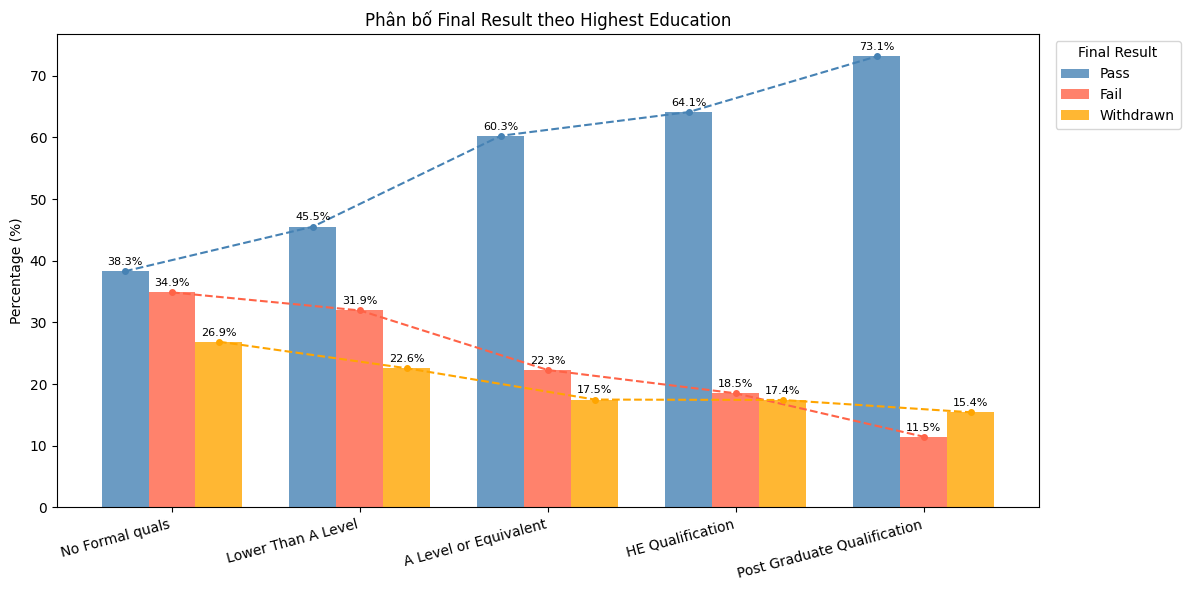

In [47]:
edu_order = [
    'No Formal quals',
    'Lower Than A Level',
    'A Level or Equivalent',
    'HE Qualification',
    'Post Graduate Qualification'
]

result_order = ['Pass', 'Fail', 'Withdrawn']
colors = ['steelblue', 'tomato', 'orange']

plot_data = (
    pd.crosstab(analysis_df['highest_education'], analysis_df['final_result'], normalize='index') * 100
)[result_order].reindex(edu_order)

x = np.arange(len(edu_order))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (result, color) in enumerate(zip(result_order, colors)):
    bars = ax.bar(x + i * width - width, plot_data[result], width, label=result, color=color, alpha=0.8)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
    # Trend line
    ax.plot(x + i * width - width, plot_data[result], 'o--', color=color, linewidth=1.5, markersize=4)

ax.set_xticks(x)
ax.set_xticklabels(edu_order, rotation=15, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Phân bố Final Result theo Highest Education')
ax.legend(title='Final Result', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Biểu đồ thể hiện tỷ lệ Pass / Fail / Withdrawn theo từng bậc học vấn của sinh viên khi nhập học.

**Xu hướng tổng thể:**

- **Pass** tăng đơn điệu theo trình độ học vấn: từ 38.3% (*No Formal quals*) lên 73.1% (*Post Graduate Qualification*) — đường trend dốc lên rõ rệt.
- **Fail** giảm ngược chiều: từ 34.9% xuống còn 11.5% — sinh viên có nền tảng học thuật cao hơn ít thất bại hơn.
- **Withdrawn** cũng giảm nhưng tốc độ chậm hơn so với Fail.

**Điểm đáng chú ý:**

- *No Formal quals* là nhóm rủi ro nhất: Pass chỉ 38.3%, trong khi Fail + Withdrawn cộng lại chiếm tới **61.7%** — nhóm duy nhất mà at-risk áp đảo.
- *Post Graduate Qualification* là nhóm duy nhất có tỉ lệ Withdrawn (15.4%) cao hơn Fail (11.5%). Sinh viên sau đại học ít thất bại về học thuật nhưng lại có xu hướng rút lui nhiều hơn, nguyên nhân có thể vì lý do cá nhân hoặc nghề nghiệp.
- Khoảng cách giữa Pass và hai nhóm at-risk **mở rộng đáng kể** từ *A Level or Equivalent* trở lên — đây có thể là ngưỡng học vấn mà nền tảng học thuật thực sự tạo ra lợi thế rõ ràng.

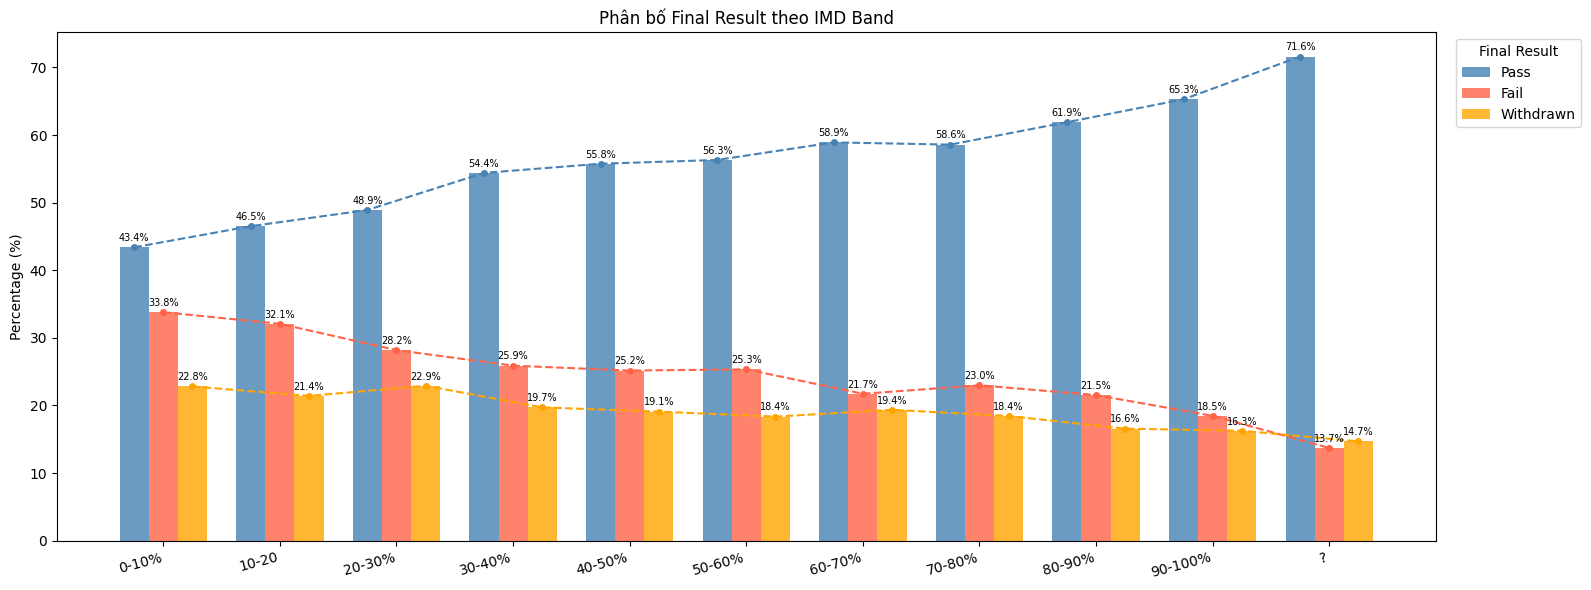

In [48]:
imd_order = ['0-10%', '10-20', '20-30%', '30-40%', '40-50%',
             '50-60%', '60-70%', '70-80%', '80-90%', '90-100%', '?']

result_order = ['Pass', 'Fail', 'Withdrawn']
colors = ['steelblue', 'tomato', 'orange']

plot_data = (
    pd.crosstab(analysis_df['imd_band'], analysis_df['final_result'], normalize='index') * 100
)[result_order].reindex(imd_order)

x = np.arange(len(imd_order))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

for i, (result, color) in enumerate(zip(result_order, colors)):
    bars = ax.bar(x + i * width - width, plot_data[result], width, label=result, color=color, alpha=0.8)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=7)
    ax.plot(x + i * width - width, plot_data[result], 'o--', color=color, linewidth=1.5, markersize=4)

ax.set_xticks(x)
ax.set_xticklabels(imd_order, rotation=15, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Phân bố Final Result theo IMD Band')
ax.legend(title='Final Result', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Biểu đồ thể hiện tỷ lệ Pass / Fail / Withdrawn theo từng nhóm IMD.

**Xu hướng tổng thể:**

- **Pass** tăng đều từ 43.4% (0-10%) lên 65.3% (90-100%) — sinh viên đến từ khu vực khá giả hơn có tỷ lệ hoàn thành cao hơn rõ rệt.
- **Fail** giảm từ 33.8% xuống 18.5% — nghịch biến với mức độ kinh tế, mức độ giảm tương đối đều
- **Withdrawn** giảm nhẹ và không đều, dao động trong khoảng 18–23% ở các band giữa, cũng có xu hướng giảm nhưng vẫn còn dao động và không giảm một cách rõ ràng và liền mạch như Fail.

**Điểm đáng chú ý:**

- Tương quan **Pass ↔ IMD Band** yếu hơn đáng kể so với tương quan **Pass ↔ Highest Education** ở biểu đồ trước — đường trend Pass dốc hơn theo học vấn (38.3% → 73.1%) so với theo IMD (43.4% → 65.3%). Điều này gợi ý nền tảng học thuật có ảnh hưởng tương đối lớn hơn điều kiện kinh tế đến kết quả học tập.
- **Withdrawn không nhạy cảm với IMD Band**: tỷ lệ dao động không đều và không giảm rõ ràng theo chiều tăng của band.
- **Nhóm `?`** có tỷ lệ Pass cao bất thường: 71.6% — cao nhất trong tất cả các nhóm, kể cả band 90-100%. 

##### **Phân tích khám phá đặc trưng động**

Để phân tích hành vi học tập theo thời gian, ta tách riêng các đặc trưng động từ `train` thành `dynamic_df`. Không giống static features (cố định từ đầu khoá học), các đặc trưng này được tính toán trong cửa sổ `[0, T]` tại mỗi mốc dự đoán — phản ánh mức độ tương tác VLE và kết quả bài kiểm tra tích luỹ đến thời điểm đó.

In [49]:
dynamic_features = [
    'total_clicks',
    'active_weeks',
    'avg_weekly_clicks',
    'num_submitted',
    'avg_score',
    'num_failed',
    'avg_days_early',
]

id_cols = ['id_student', 'code_module', 'code_presentation', 'prediction_point']

dynamic_df = train[id_cols + dynamic_features + ['final_result']].copy()

dynamic_df.head()

,id_student,code_module,code_presentation,prediction_point,total_clicks,active_weeks,avg_weekly_clicks,num_submitted,avg_score,num_failed,avg_days_early,final_result
0,11391,AAA,2013J,30,427.0,5.0,85.400000,1.0,78.0,0.0,1.0,Pass
1,28400,AAA,2013J,30,625.0,7.0,89.285714,1.0,70.0,0.0,-3.0,Pass
2,31604,AAA,2013J,30,566.0,7.0,80.857143,1.0,72.0,0.0,2.0,Pass
3,38053,AAA,2013J,30,764.0,7.0,109.142857,1.0,79.0,0.0,0.0,Pass
4,45462,AAA,2013J,30,610.0,6.0,101.666667,1.0,70.0,0.0,-1.0,Pass


In [50]:
dynamic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142384 entries, 0 to 142383
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id_student         142384 non-null  int64  
 1   code_module        142384 non-null  object 
 2   code_presentation  142384 non-null  object 
 3   prediction_point   142384 non-null  int64  
 4   total_clicks       139934 non-null  float64
 5   active_weeks       139934 non-null  float64
 6   avg_weekly_clicks  139934 non-null  float64
 7   num_submitted      129388 non-null  float64
 8   avg_score          127544 non-null  float64
 9   num_failed         129388 non-null  float64
 10  avg_days_early     129388 non-null  float64
 11  final_result       142384 non-null  object 
dtypes: float64(7), int64(2), object(3)
memory usage: 13.0+ MB


In [51]:
dynamic_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id_student,142384.0,709006.399223,563054.520854,8462.0,498455.000000,585074.000000,640752.000000,2710343.0
prediction_point,142384.0,130.209996,68.868787,30.0,60.000000,120.000000,180.000000,240.0
total_clicks,139934.0,1072.269320,1358.444418,1.0,269.000000,617.000000,1334.000000,23115.0
active_weeks,139934.0,15.646984,9.213184,1.0,8.000000,14.000000,22.000000,39.0
avg_weekly_clicks,139934.0,60.742622,56.398596,1.0,25.444444,44.085145,76.921474,1070.5
num_submitted,129388.0,3.809596,2.684697,1.0,2.000000,3.000000,5.000000,14.0
avg_score,127544.0,73.540556,15.513499,0.0,64.730000,76.000000,85.000000,100.0
num_failed,129388.0,0.163323,0.494247,0.0,0.000000,0.000000,0.000000,8.0
avg_days_early,129388.0,0.936219,8.099832,-123.0,-1.500000,0.000000,1.500000,236.0


- VLE features lệch phải mạnh: `total_clicks` có std (1,358) vượt mean (1,072) — phân phối bị kéo bởi outliers, max lên tới 23,115. `avg_weekly_clicks` tương tự: mean=60.7 nhưng max=1,070.5. 

- `num_failed`: min = median = Q3 = 0 — phần lớn sinh viên không trượt bài nào trong cửa sổ quan sát. Mean chỉ 0.16, max = 8 - vẫn có nhóm nhỏ sinh viên có nhiều bài trượt.

- `avg_days_early` có khoảng giá trị cực rộng: min = −123 (nộp trễ 123 ngày) đến max = 236 (nộp sớm 236 ngày). Median = 0 — một nửa sinh viên nộp đúng hạn hoặc trễ, nửa còn lại nộp trước. Q1 và Q3 lần lượt là -1.5 và 1.5 cho thấy khoảng 50% sinh viên nộp bài từ sớm hơn deadline khoảng hơn 1 ngày đến muộn hơn deadline khoảng hơn 1 ngày. Outliers ở cả hai đầu cũng cần được kiểm tra kĩ càng.

- `avg_score` tương đối tập trung: Q1 = 64.7, Q3 = 85 — phần lớn sinh viên có điểm trung bình nằm trong khoảng khá đến tốt.

##### Phân tích số lượng sinh viên còn học sau mỗi 30 ngày

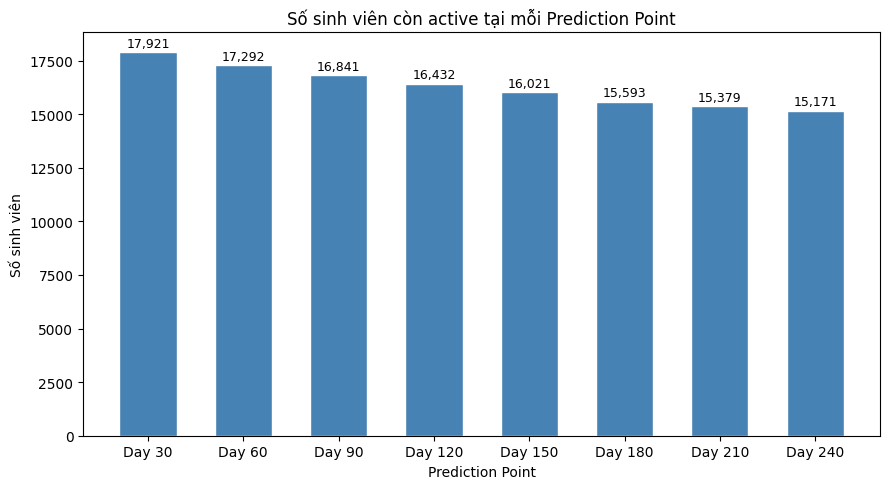

In [52]:
students_per_point = (
    dynamic_df.groupby('prediction_point')['id_student']
    .nunique()
    .reset_index(name='num_students')
)

plt.figure(figsize=(9, 5))
bars = plt.bar(
    students_per_point['prediction_point'],
    students_per_point['num_students'],
    width=18, color='steelblue', edgecolor='white'
)

for bar, val in zip(bars, students_per_point['num_students']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.xticks(SNAPSHOTS, [f'Day {t}' for t in SNAPSHOTS])
plt.xlabel('Prediction Point')
plt.ylabel('Số sinh viên')
plt.title('Số sinh viên còn active tại mỗi Prediction Point')
plt.tight_layout()
plt.show()

In [53]:
students_per_point['delta'] = students_per_point['num_students'].diff().astype('Int64')

prev = students_per_point['prediction_point'].shift(1).astype('Int64')
students_per_point['interval'] = prev.combine(
    students_per_point['prediction_point'],
    lambda a, b: f'Day {a} → Day {b}' if pd.notna(a) else None
)

delta_df = students_per_point.dropna(subset=['delta']).copy()

# Delta lớn nhất / nhỏ nhất (theo abs)
max_row = delta_df.loc[delta_df['delta'].abs().idxmax()]
min_row = delta_df.loc[delta_df['delta'].abs().idxmin()]

print("=" * 45)
print(f"Delta lớn nhất : {max_row['delta']:>6,}  ({max_row['interval']})")
print(f"Delta nhỏ nhất : {min_row['delta']:>6,}  ({min_row['interval']})")
print(f"Trung bình delta: {delta_df['delta'].mean():.1f} sinh viên/30 ngày")
print("=" * 45)

delta_df[['interval', 'num_students', 'delta']]

Delta lớn nhất :   -629  (Day 30 → Day 60)
Delta nhỏ nhất :   -208  (Day 210 → Day 240)
Trung bình delta: -392.9 sinh viên/30 ngày


,interval,num_students,delta
1,Day 30 → Day 60,17292,-629
2,Day 60 → Day 90,16841,-451
3,Day 90 → Day 120,16432,-409
4,Day 120 → Day 150,16021,-411
5,Day 150 → Day 180,15593,-428
6,Day 180 → Day 210,15379,-214
7,Day 210 → Day 240,15171,-208


- Số sinh viên active giảm đều qua các mốc: từ **17,921** (Day 30) xuống còn **15,171** (Day 240) — tổng cộng **2,750 sinh viên** rút khỏi khoá học trong vòng 210 ngày quan sát (~15.3%).

- Mức giảm lớn nhất xảy ra ở giai đoạn đầu (**Day 30 → Day 60**: −629), sau đó xu hướng rõ ràng: delta giảm dần và ổn định hơn về cuối khoá — **Day 180 → Day 210** (−214) và **Day 210 → Day 240** (−208) chỉ bằng khoảng 1/3 so với giai đoạn đầu.

- Trung bình mỗi 30 ngày mất **~393 sinh viên**, nhưng con số này không đại diện tốt vì phân phối lệch về phía đầu khoá — giai đoạn 30–90 ngày đầu chiếm phần lớn tổng Withdrawn.


##### Phân tích tương quan

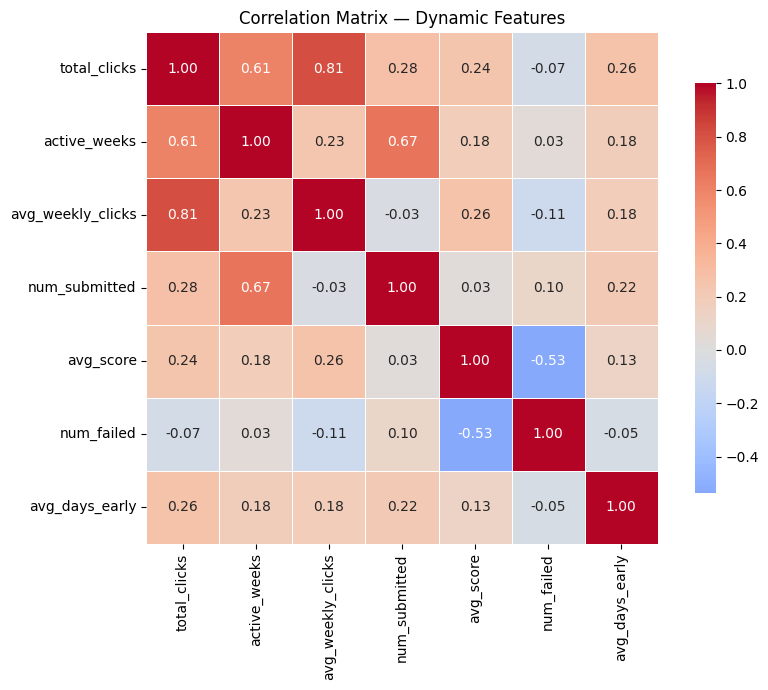

In [54]:
corr = dynamic_df[dynamic_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix — Dynamic Features')
plt.tight_layout()
plt.show()

- **Cụm hoạt động online** (`total_clicks`, `active_weeks`, `avg_weekly_clicks`) tương quan chặt với nhau, đặc biệt `total_clicks` và `avg_weekly_clicks` gần như cùng đo một thứ — nếu đưa cả hai vào model thì có thể xảy ra đa cộng tuyến multicollinearity. `active_weeks` liên kết tốt với `num_submitted`: học sinh duy trì hoạt động đều đặn thì nộp bài nhiều hơn, nhưng click nhiều mỗi tuần không dẫn đến nộp bài nhiều hơn (`avg_weekly_clicks` vs `num_submitted` gần bằng 0) — gợi ý click không phải lúc nào cũng là tương tác có mục đích.

- **Cặp nghịch chiều rõ nhất** là `avg_score` và `num_failed`: điểm trung bình cao đi kèm với số bài trượt thấp — hai feature này phản ánh cùng một chiều rủi ro từ hai phía, có thể chỉ cần giữ một trong model.

- **`avg_days_early`** (nộp bài sớm bao nhiêu ngày) tương quan thấp với hầu hết các feature còn lại — đây là tín hiệu khá độc lập, đo hành vi quản lý thời gian, không bị che bởi các chỉ số hoạt động khác.

- **`num_failed`** gần như không tương quan với các feature hoạt động (`total_clicks`, `active_weeks`...) — cho thấy click nhiều hay học đều không tự động ngăn được việc trượt bài; chất lượng thực sự của việc học mới quyết định.

**Tóm lại:** không có feature nào thừa hoàn toàn, nhưng cặp `total_clicks`/`avg_weekly_clicks` cần được xem xét kỹ trước khi đưa vào model để tránh multicollinearity.

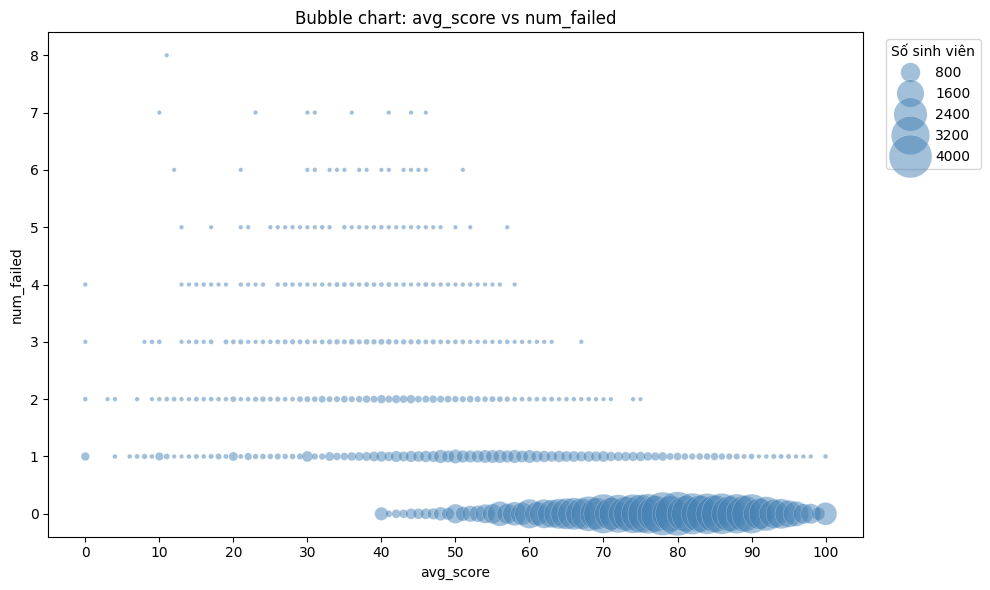

In [73]:
plot_data = (
    dynamic_df
    .assign(avg_score_bin=dynamic_df['avg_score'].round(0))  
    .groupby(['avg_score_bin', 'num_failed'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='avg_score_bin', y='num_failed',
    size='count', sizes=(10, 1000),
    alpha=0.5, color='steelblue', legend='brief',
    data=plot_data
)
plt.xlabel('avg_score')
plt.ylabel('num_failed')
plt.xticks(range(0,101,10))
plt.title('Bubble chart: avg_score vs num_failed')
plt.legend(title='Số sinh viên', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

- **Phần lớn sinh viên nằm ở `num_failed = 0`**, và trong nhóm này avg_score tập trung cao — bubble lớn nhất xuất hiện từ khoảng 60 điểm trở lên, peak rõ ở vùng 80–100. Đây là nhóm đông nhất và có profile học tập tốt nhất.

- **Mối quan hệ nghịch chiều tồn tại nhưng không tuyệt đối.** Khi `num_failed` tăng lên, bubble nhỏ dần và phân bố avg_score loãng ra:

    - **`num_failed = 1`** — hàng đông nhất trong nhóm đã từng trượt. Bubble trải đều từ gần 0 đến 100 điểm, không có vùng tập trung rõ ràng. Điều này gợi ý trượt đúng 1 bài là hiện tượng phổ biến ở mọi mức năng lực — có thể do vắng một buổi, nộp trễ, hoặc một bài khó cụ thể, chứ không nhất thiết phản ánh rủi ro tổng thể.

    - **`num_failed = 2`** — phân bố vẫn còn rải rộng nhưng avg_score cao nhất đã giảm xuống khoảng 70-80. 

    - **`num_failed = 3, 4, 5`** — phân bố bắt đầu dịch về phía trái, bubble ở vùng avg_score thấp (<40) xuất hiện nhiều hơn tương đối.

    - **`num_failed = 6, 7, 8`** — rất ít sinh viên (bubble rất nhỏ). Ở `num_failed = 7, 8`, avg_score chủ yếu tập trung ở vùng thấp (dưới 40) — đây là nhóm rủi ro cao nhất, cả hai chiều đều xấu.

    - **Điểm đáng chú ý xuyên suốt:** ở một số mức `num_failed` thấp (1-5), vẫn tồn tại sinh viên có avg_score ở mức trung bình - khá thậm chí một số ít còn đạt kết quả tốt. Đây là lý do `avg_score` và `num_failed` không thể thay thế nhau — `num_failed` bắt được một kiểu rủi ro mà điểm số bỏ qua: sinh viên học ổn nhưng bỏ/trượt một số bài, có thể do vấn đề cam kết hoặc hoàn cảnh cá nhân hơn là năng lực thuần túy.




##### Phân tích theo nhãn mục tiêu

In [56]:
dynamic_df.groupby('final_result')[dynamic_features].mean()

,total_clicks,active_weeks,avg_weekly_clicks,num_submitted,avg_score,num_failed,avg_days_early
final_result,,,,,,,
Fail,548.590111,11.062361,42.486274,3.076135,63.480067,0.330001,-0.193523
Pass,1377.989576,18.484917,70.236365,4.272566,78.209993,0.088391,1.586727
Withdrawn,542.775431,9.926537,50.106064,2.290006,65.465847,0.270763,-0.912556


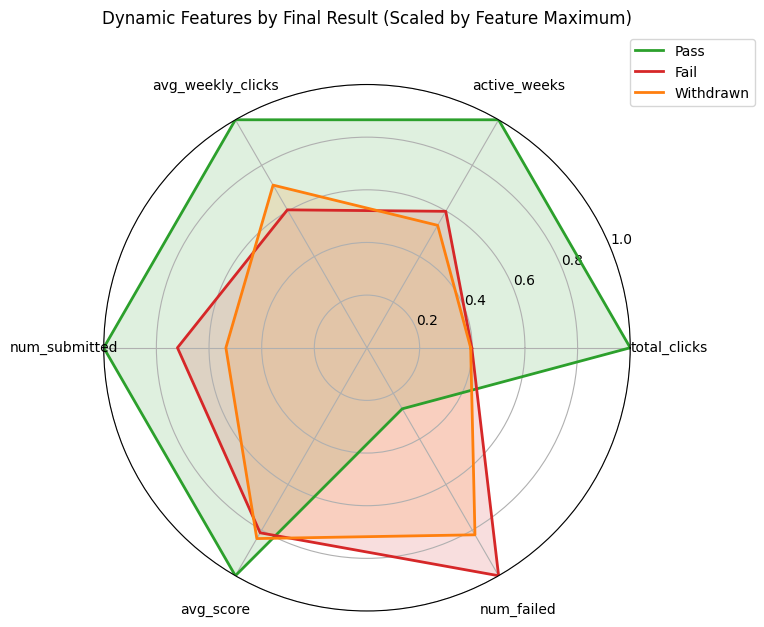

In [75]:
radar_features = [f for f in dynamic_features if f != 'avg_days_early']
group_means = dynamic_df.groupby('final_result')[radar_features].mean()

# Chia mỗi feature cho giá trị lớn nhất của chính feature đó
normalized = group_means / group_means.max()

labels = radar_features
num_vars = len(labels)

angles = np.linspace(
    0,
    2 * np.pi,
    num_vars,
    endpoint=False
).tolist()

angles += angles[:1]

colors = {
    'Pass': 'tab:green',
    'Fail': 'tab:red',
    'Withdrawn': 'tab:orange'
}

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

for group in ['Pass', 'Fail', 'Withdrawn']:
    values = normalized.loc[group].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=group,
        color=colors[group]
    )

    ax.fill(
        angles,
        values,
        alpha=0.15,
        color=colors[group]
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels([])

for angle, label in zip(angles[:-1], labels):
    ax.text(
        angle,
        1.15,
        label,
        ha='center',
        va='center',
        fontsize=10
    )

ax.set_ylim(0, 1)

ax.set_title(
    'Dynamic Features by Final Result (Scaled by Feature Maximum)',
    y=1.1
)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.25, 1.1)
)

plt.tight_layout()
plt.show()

- Nhóm **Pass** chiếm diện tích lớn nhất, đặc biệt vượt trội ở ba đặc trưng tương tác VLE — `active_weeks`, `total_clicks` và `avg_weekly_clicks` đều cao hơn hẳn so với hai nhóm còn lại. Ngoài ra, số lượng nộp bài của nhóm Pass cũng hơn hẳn hai nhóm Fail và Withdraw. Đây là nhóm duy nhất duy trì được cả hai khía cạnh: mức độ tham gia học tập cao và kết quả bài kiểm tra tốt (`avg_score` cao, `num_failed` thấp)

- Nhóm **Fail** có profile đặc trưng nhất ở trục `num_failed` — cao hơn cả Pass và Withdrawn — trong khi `num_submitted` lại ở mức tương đương Pass. Điều này cho thấy sinh viên Fail **không thiếu nỗ lực về số lượng** — họ vẫn nộp bài đầy đủ — nhưng chất lượng đầu ra không đạt, phản ánh một dạng khó khăn học thuật kéo dài hơn là sự buông bỏ.

- Nhóm **Withdrawn** lại có pattern ngược lại hoàn toàn: `num_submitted` thấp nhất trong ba nhóm, trong khi `num_failed` gần như bằng 0. Ở đây, ta thấy không phải là nhóm này làm bài tốt, mà là họ **còn không nộp bài để mà trượt**. Đáng chú ý, `avg_score` của nhóm Withdrawn ở mức trung bình — những bài có nộp không hẳn là kém — điều này gợi ý rằng việc rút khỏi khoá học không phải từ thất bại học thuật tức thời.

Nhìn chung, biểu đồ khẳng định rằng Fail và Withdrawn đại diện cho **hai cơ chế rủi ro khác biệt về bản chất**: một bên là khó khăn trong việc đạt yêu cầu học thuật, bên kia là sự rút lui khỏi quá trình học tập. Sự phân biệt này có hàm ý quan trọng cho việc thiết kế model — hai nhóm cần được nhận diện qua các tín hiệu feature khác nhau, và can thiệp sư phạm cho mỗi nhóm cũng cần theo hướng khác nhau.

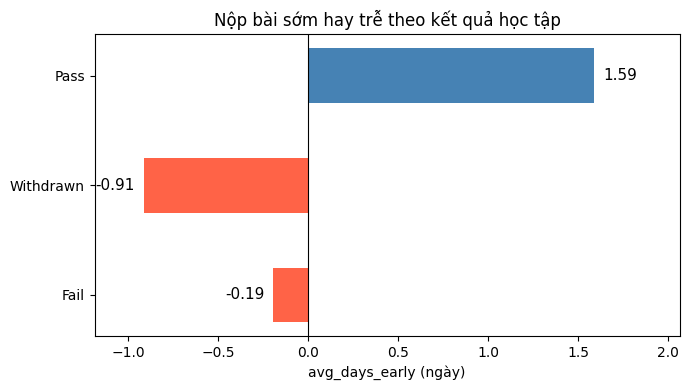

In [74]:
avg_days = dynamic_df.groupby('final_result')['avg_days_early'].mean()
avg_days = avg_days.loc[['Fail', 'Withdrawn', 'Pass']]

colors = ['tomato' if v < 0 else 'steelblue' for v in avg_days.values]

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.barh(avg_days.index, avg_days.values, color=colors, height=0.5)

ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, avg_days.values):
    offset = 0.05 if val >= 0 else -0.05
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha=ha, fontsize=11)

ax.set_xlabel('avg_days_early (ngày)')
ax.set_title('Nộp bài sớm hay trễ theo kết quả học tập')
ax.set_xlim(avg_days.min() * 1.3, avg_days.max() * 1.3)

plt.tight_layout()
plt.show()

Biểu đồ thể hiện giá trị trung bình của `avg_days_early` theo từng nhóm kết quả học tập, trong đó giá trị dương nghĩa là nộp bài trước hạn và giá trị âm nghĩa là nộp trễ.

- Nhóm **Pass** là nhóm duy nhất có `avg_days_early` dương (+1.59 ngày), cho thấy sinh viên hoàn thành khoá học có xu hướng nộp bài trước deadline. Dù con số tuyệt đối không lớn, chiều hướng này phản ánh thái độ chủ động và có tổ chức trong việc hoàn thành nhiệm vụ học tập.

- Ngược lại, cả hai nhóm at-risk đều có giá trị âm. Nhóm **Withdrawn** có mức trễ lớn nhất (−0.91 ngày) — lớn gấp gần 5 lần so với nhóm **Fail** (−0.19 ngày). Điều này nhất quán với profile đã quan sát ở radar chart: sinh viên Withdrawn không chỉ nộp ít bài hơn mà những bài có nộp cũng có xu hướng nộp trễ, củng cố thêm cho nhận định về sự mất gắn kết dần dần với khoá học.

Đáng chú ý, khoảng cách giữa ba nhóm tuy có ý nghĩa về chiều hướng nhưng về độ lớn tuyệt đối đều khá nhỏ (dưới 2 ngày) cho thấy rằng `avg_days_early` có thể không phải feature mạnh nhất khi đứng độc lập.

##### **Lưu train/test split ra file Parquet**

In [62]:
from pathlib import Path
Path("../data/processed").mkdir(exist_ok=True)
train.to_parquet("../data/processed/train.parquet", index=False)
test.to_parquet("../data/processed/test.parquet", index=False)
print(f"Saved: train {train.shape}, test {test.shape}")

Saved: train (142384, 22), test (35910, 22)
